In [1]:
import os
os.environ['PATH'] = '/home/irman/Gelochip/.venv/bin:' + os.environ.get('PATH', '')
import sys, os
os.environ.setdefault('PDK_ROOT', os.path.expanduser('~/pdks'))
sys.path.insert(0, '/home/irman/Gelochip/src/gelochip')

import klayout.db as kdb
import klayout.lay as klay
from IPython.display import Image, display

def show_gds(gds_path, out_png=None, width=1600, height=900):
    gds_abs = os.path.abspath(gds_path)
    if not os.path.exists(gds_abs):
        print(f'GDS not found: {gds_abs}'); return
    out_png = out_png or gds_abs.replace('.gds', '_preview.png')
    lv = klay.LayoutView()
    lv.load_layout(gds_abs, True)
    lv.max_hier(); lv.zoom_fit()
    lv.save_image(out_png, width, height)
    display(Image(out_png))




2026-05-18 20:35:31.775 | WARNING  | gdsfactory.pdk:get_active_pdk:733 - No active PDK. Activating generic PDK.



2026-05-18 20:35:32.100 | INFO     | gdsfactory.technology.layer_views:__init__:790 - Importing LayerViews from YAML file: '/home/irman/Gelochip/.venv/lib/python3.13/site-packages/gdsfactory/generic_tech/layer_views.yaml'.


2026-05-18 20:35:32.101 | INFO     | gdsfactory.pdk:activate:337 - 'generic' PDK is now active


2026-05-18 20:35:32.112 | INFO     | gdsfactory.pdk:activate:337 - 'gf180' PDK is now active


2026-05-18 20:35:38.946 | INFO     | gdsfactory.component:_write_library:1851 - Wrote to 'p_block.gds'


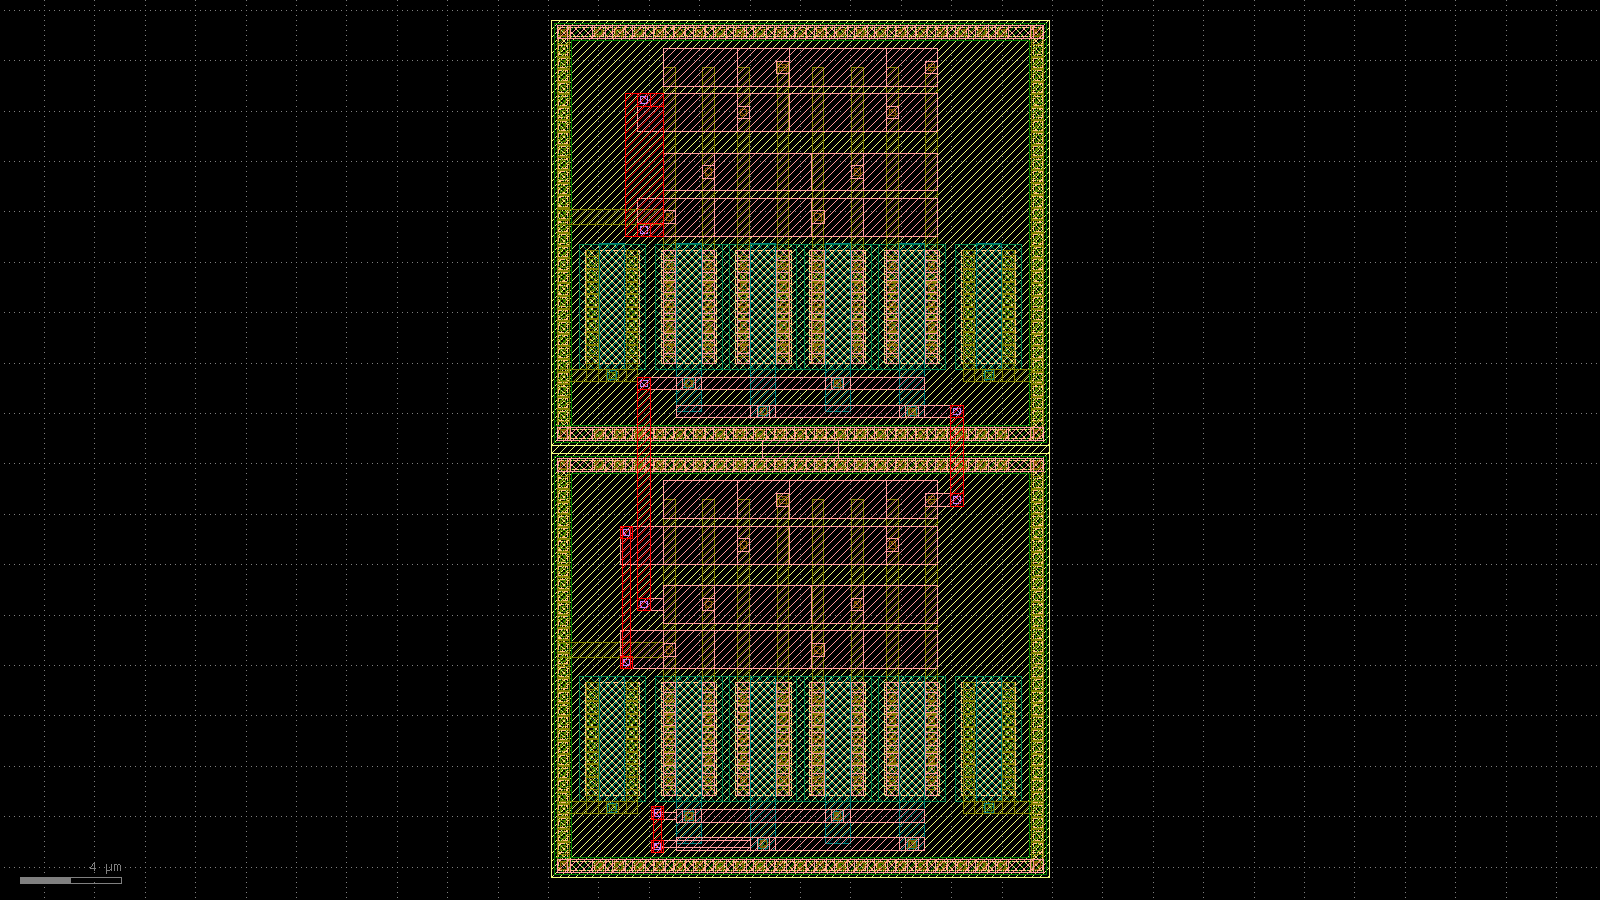

2026-05-18 20:35:39.015 | INFO     | gdsfactory.component:_write_library:1851 - Wrote to '/tmp/tmpyd4u2_1n/p_block$2.gds'


using default pdk_root
Defaulting to stale magic_commands.tcl


2026-05-18 20:35:39.255 | INFO     | gdsfactory.component:_write_library:1851 - Wrote to '/tmp/tmp5_fq1n3_/p_block$2.gds'



Magic 8.3 revision 644 - Compiled on Sun May 17 10:32:25 PM WIB 2026.
Starting magic under Tcl interpreter
Using the terminal as the console.
Using NULL graphics device.
Processing system .magicrc file
Switching to WIRING tool.
Switching to NETLIST tool.
Switching to PICK tool.
Switching to BOX tool.
Sourcing design .magicrc for technology gf180mcuD ...
10 Magic internal units = 1 Lambda
Input style import: scaleFactor=10, multiplier=2
The following types are not handled by extraction and will be treated as non-electrical types:
    obsactive mvobsactive filldiff fillpoly m1hole obsm1 fillm1 obsv1 m2hole obsm2 fillm2 obsv2 m3hole obsm3 fillm3 m4hole obsm4 fillm4 m5hole obsm5 fillm5 glass fillblock lvstext obscomment 
Scaled tech values by 10 / 1 to match internal grid scaling
Loading gf180mcuD Device Generator Menu ...
Loading "/tmp/tmpyd4u2_1n/magic_commands.tcl" from command line.
Library written using GDS-II Release 6.0
Library name: library
Reading "p_block$2".
[INFO]: Loading p_b

In [2]:
import sys
try:
    cm_mod = sys.modules['glayout.cells.elementary.current_mirror.current_mirror']
    if not hasattr(cm_mod, 'orig_cmn'):
        orig_cmn = cm_mod.current_mirror_netlist
        cm_mod.orig_cmn = orig_cmn
        def patched_cmn(pdk, width, length, multipliers, fingers=1, **kwargs):
            netlist = orig_cmn(pdk, width=width, length=length, multipliers=multipliers, fingers=fingers, **kwargs)
            if 'B' in netlist.nodes:
                idx = netlist.nodes.index('B')
                netlist.nodes[idx] = 'VB'
            if 'VOUT' in netlist.nodes:
                idx = netlist.nodes.index('VOUT')
                netlist.nodes[idx] = 'VCOPY'
            return netlist
        cm_mod.current_mirror_netlist = patched_cmn
        for modname, mod in list(sys.modules.items()):
            if hasattr(mod, 'current_mirror_netlist'):
                setattr(mod, 'current_mirror_netlist', patched_cmn)
except Exception as e:
    pass

from glayout.pdk.mappedpdk import MappedPDK
from glayout.pdk.gf180_mapped import gf180_mapped_pdk
from gdsfactory.cell import cell
from gdsfactory.component import Component
from gdsfactory.component_reference import ComponentReference
from gdsfactory import Component
from glayout.primitives.fet import nmos, pmos, multiplier
from glayout.util.comp_utils import evaluate_bbox, prec_center, prec_ref_center
from glayout.util.snap_to_grid import component_snap_to_grid
from glayout.util.port_utils import rename_ports_by_orientation
from glayout.routing.straight_route import straight_route
from glayout.routing.c_route import c_route
from glayout.routing.L_route import L_route
from glayout.primitives.guardring import tapring
from glayout.util.port_utils import add_ports_perimeter, rename_ports_by_list
from glayout.spice.netlist import Netlist
from glayout.primitives.via_gen import via_stack
from gdsfactory.components import text_freetype, rectangle
from glayout.placement.four_transistor_interdigitized import generic_4T_interdigitzed

# Fix generic_4T_interdigitzed: substrate_tap_ref unbound when with_substrate_tap=False
import glayout.placement.four_transistor_interdigitized as _ft_mod
from glayout.placement.two_transistor_interdigitized import two_nfet_interdigitized as _2ni, two_pfet_interdigitized as _2pi
from glayout.placement.four_transistor_interdigitized import four_tran_interdigitized_netlist as _4tn
from glayout.util.comp_utils import evaluate_bbox as _ebbox, movey as _mvy
from glayout.primitives.guardring import tapring as _tapring
from gdsfactory.component import Component as _Cmp

def _fixed_g4t(pdk, top_row_device="pfet", bottom_row_device="nfet", numcols=3, length=None, with_substrate_tap=True, top_kwargs=None, bottom_kwargs=None):
    top_kwargs = top_kwargs or {}
    bottom_kwargs = bottom_kwargs or {}
    toplvl = _Cmp()
    toprow = toplvl << (_2ni if top_row_device=="nfet" else _2pi)(pdk, numcols, with_substrate_tap=False, length=length, **top_kwargs)
    bottomrow = toplvl << (_2ni if bottom_row_device=="nfet" else _2pi)(pdk, numcols, with_substrate_tap=False, length=length, **bottom_kwargs)
    toprow.movey(pdk.snap_to_2xgrid((_ebbox(bottomrow)[1]/2 + _ebbox(toprow)[1]/2 + pdk.util_max_metal_seperation())))
    if with_substrate_tap:
        substrate_tap = _tapring(pdk, enclosed_rectangle=pdk.snap_to_2xgrid(_ebbox(toplvl.flatten(), padding=0.34)))
        substrate_tap_ref = toplvl << _mvy(substrate_tap, destination=pdk.snap_to_2xgrid(toplvl.flatten().center[1], snap4=True))
        toplvl.add_ports(substrate_tap_ref.get_ports_list(), prefix="substratetap_")
    toplvl.add_ports(toprow.get_ports_list(), prefix="top_")
    toplvl.add_ports(bottomrow.get_ports_list(), prefix="bottom_")
    toplvl.info["route_genid"] = "four_transistor_interdigitized"
    same_bulk = (top_row_device == bottom_row_device and top_row_device == "nfet")
    toplvl.info['netlist'] = _4tn(toprow, bottomrow, same_bulk)
    return toplvl

_ft_mod.generic_4T_interdigitzed = _fixed_g4t
generic_4T_interdigitzed = _fixed_g4t


def p_block_netlist(pdk: MappedPDK, pblock: tuple[float, float, int]) -> Netlist:
    return Netlist(
        circuit_name="p_block",
        nodes=['MA_1_D', 'MA_2_D', 'MA_G', 'MB_1_D', 'MB_2_D', 'VDD'],
        source_netlist=""".subckt {circuit_name} {nodes} """ + f'l={pblock[1]} wb={pblock[0]} wt={pblock[0] * pblock[2]} ' + """
XTOP1 MB_1_D MA_1_D VDD VDD {model} l={{l}} w={{wt}} 
XTOP2 MB_2_D MA_2_D VDD VDD {model} l={{l}} w={{wt}} 
XBOT1 MA_1_D MA_G VDD VDD {model} l={{l}} w={{wb}} 
XBOT2 MA_2_D MA_G VDD VDD {model} l={{l}} w={{wb}} 
.ends {circuit_name}""",
        instance_format="X{name} {nodes} {circuit_name} l={length} wt={width_top} wb={width_bot}",
        parameters={
            'model': pdk.models['pfet'],
            'width_top': pblock[0] * pblock[2],
            'width_bot': pblock[0],
            'length': pblock[1],
        }
    )


@cell
def  p_block(
        pdk: MappedPDK,
        width: float = 4.5,
        length: float = 1,
        fingers: int = 1,
        ratio: int = 1,
        ) -> Component:
    """
    p_block for super class AB OTA

    """
    #top level component
    top_level = Component(name="p_block")
    top_kwargs = {
            "fingers": ratio*fingers,
            "width": width,
            "with_tie": True,
            "sd_rmult":3
            }
    bottom_kwargs = {
            "fingers": fingers,
            "width": width,
            "with_tie": True,
            "sd_rmult":3
            }

    p_block = generic_4T_interdigitzed(pdk, top_row_device = "pfet", bottom_row_device = "pfet", numcols = 2, length = length, with_substrate_tap = False, top_kwargs = top_kwargs, bottom_kwargs = bottom_kwargs)
    p_block_ref = top_level << p_block

    top_level << c_route(pdk, p_block.ports["top_A_0_gate_W"], p_block.ports["bottom_A_0_drain_W"])
    top_level << c_route(pdk, p_block.ports["top_B_1_gate_E"], p_block.ports["bottom_B_1_drain_E"])
    top_level << c_route(pdk, p_block.ports["bottom_A_0_gate_W"], p_block.ports["bottom_B_0_gate_W"], width1=0.29, width2=0.29, cwidth=0.29)
    
    top_level << c_route(pdk, p_block.ports["top_A_0_source_W"], p_block.ports["top_B_0_source_W"])
    top_level << straight_route(pdk, p_block.ports["top_A_0_source_W"], p_block.ports["top_welltie_W_top_met_W"], glayer1='met1', width=0.6)
    top_level << c_route(pdk, p_block.ports["bottom_A_0_source_W"], p_block.ports["bottom_B_0_source_W"], extension=1.2, cwidth=0.29)
    top_level << straight_route(pdk, p_block.ports["bottom_A_0_source_W"], p_block.ports["bottom_welltie_W_top_met_W"], glayer1='met1', width=0.6)
    
    top_level << straight_route(pdk, p_block.ports["top_welltie_S_top_met_S"], p_block.ports["bottom_welltie_N_top_met_N"], glayer1='met2', width=3)
    
    #adding a nwell    
    nwell_rectangle = rectangle(layer=(pdk.get_glayer("nwell")), size=evaluate_bbox(top_level))
    nwell_rectangle_ref = prec_ref_center(nwell_rectangle)
    nwell_rectangle_ref.move(p_block_ref.center) 
    top_level.add(nwell_rectangle_ref)

    #Renaming Ports
    top_level.add_ports(p_block.get_ports_list())
    
    component = component_snap_to_grid(rename_ports_by_orientation(top_level))
    # Store netlist as string to avoid gymnasium info dict type restrictions
    # Compatible with both gdsfactory 7.7.0 and 7.16.0+ strict Pydantic validation
    netlist_obj = p_block_netlist(pdk, pblock=(width,length,ratio))
    component.info['netlist_obj'] = netlist_obj
    component.info['netlist'] = netlist_obj.generate_netlist() if hasattr(netlist_obj, 'generate_netlist') else str(netlist_obj)
    # Store serialized netlist data for reconstruction if needed
    component.info['netlist_data'] = {
        'circuit_name': netlist_obj.circuit_name,
        'nodes': netlist_obj.nodes,
        'source_netlist': netlist_obj.source_netlist
    }
    #print(component.info['netlist'].generate_netlist())

    return component


from glayout.pdk.gf180_mapped import gf180_mapped_pdk
comp = p_block(gf180_mapped_pdk)
comp.write_gds("p_block.gds")
show_gds("p_block.gds")

comp.name = 'p_block'
# DRC with magic (graceful if magic not installed)
try:
    drc_result = gf180_mapped_pdk.drc_magic(comp, comp.name)
    print('DRC:', drc_result)
except Exception as e:
    print(f'DRC skipped: {e}')
# LVS with netgen (graceful if netgen not installed)
try:
    lvs_result = gf180_mapped_pdk.lvs_netgen(comp, comp.name)
    print('LVS:', lvs_result['result_str'])
except Exception as e:
    print(f'LVS skipped: {e}')


In [3]:
try:
    from glayout.verification.evaluator_wrapper import run_evaluation
except ImportError:
    print("Warning: evaluator_wrapper not found. Evaluation will be skipped.")
    run_evaluation = None

if run_evaluation is not None:
    result = run_evaluation("p_block.gds", comp.name, comp)
    print(result)


2026-05-18 20:35:39.404 | INFO     | gdsfactory.component:_write_library:1851 - Wrote to '/home/irman/Gelochip/notebooks/datasets/p_block/P_BLOCK.gds'


--- Starting Comprehensive Evaluation for p_block$2 ---
Cleaning up intermediate files for component 'p_block$2'...
  - Deleted directory: p_block$2_drc_out
  - Deleted directory: p_block$2_lvs_out
Running verification checks (DRC, LVS)...
using default pdk_root
Defaulting to stale magic_commands.tcl


2026-05-18 20:35:39.617 | INFO     | gdsfactory.component:_write_library:1851 - Wrote to '/tmp/tmp95k28roa/P_BLOCK.gds'



Magic 8.3 revision 644 - Compiled on Sun May 17 10:32:25 PM WIB 2026.
Starting magic under Tcl interpreter
Using the terminal as the console.
Using NULL graphics device.
Processing system .magicrc file
Switching to WIRING tool.
Switching to NETLIST tool.
Switching to PICK tool.
Switching to BOX tool.
Sourcing design .magicrc for technology gf180mcuD ...
10 Magic internal units = 1 Lambda
Input style import: scaleFactor=10, multiplier=2
The following types are not handled by extraction and will be treated as non-electrical types:
    obsactive mvobsactive filldiff fillpoly m1hole obsm1 fillm1 obsv1 m2hole obsm2 fillm2 obsv2 m3hole obsm3 fillm3 m4hole obsm4 fillm4 m5hole obsm5 fillm5 glass fillblock lvstext obscomment 
Scaled tech values by 10 / 1 to match internal grid scaling
Loading gf180mcuD Device Generator Menu ...
Loading "/tmp/tmpl3ostsb2/magic_commands.tcl" from command line.
Library written using GDS-II Release 6.0
Library name: library
Reading "P_BLOCK".
[INFO]: Loading P_BLO

Netgen 1.5.272 compiled on Mon May 18 06:54:31 AM WIB 2026
Reading netlist file /tmp/tmp95k28roa/P_BLOCK_lvsmag.spice
Call to undefined subcircuit pfet_03v3
Creating placeholder cell definition.
Reading netlist file /tmp/tmp95k28roa/P_BLOCK.spice
Call to undefined subcircuit pmos_3p3
Creating placeholder cell definition.
Call to undefined subcircuit nmos_3p3
Creating placeholder cell definition.
Call to undefined subcircuit pfet_03v3
Creating placeholder cell definition.

Reading setup file /home/irman/pdks/gf180mcuD/libs.tech/netgen/gf180mcuD_setup.tcl

No property area found for device c
Model pfet_03v3 pin 1 == 3
No property par1 found for device pfet_03v3
No property NRD found for device pfet_03v3
No property NRS found for device pfet_03v3
No property par found for device pfet_03v3
No property sa found for device pfet_03v3
No property sb found for device pfet_03v3
No property sd found for device pfet_03v3
No property par found for device pfet_03v3
No property dtemp found for device

--- Evaluation complete. Results saved to p_block$2_2.json ---
{'component_name': 'p_block$2', 'timestamp': '2026-05-18T20:35:40.950329', 'drc_lvs_fail': True, 'drc': {'status': 'pass', 'is_pass': True, 'report_path': '/home/irman/Gelochip/notebooks/datasets/p_block/P_BLOCK_drc_out/drc/P_BLOCK/P_BLOCK.rpt', 'summary': {'is_pass': True, 'total_errors': 0, 'error_details': []}}, 'lvs': {'status': 'fail', 'is_pass': False, 'report_path': '/home/irman/Gelochip/notebooks/datasets/p_block/P_BLOCK_lvs_out/lvs/P_BLOCK/P_BLOCK_lvs.rpt', 'summary': {'is_pass': False, 'conclusion': 'LVS Fail: Netlist mismatch.', 'total_mismatches': 1, 'mismatch_details': {'nets': '6                          |Number of nets: 6', 'devices': '5 **Mismatch**          |Number of devices: 4 **Mismatch**', 'unmatched_nets_parsed': [], 'unmatched_instances_parsed': [{'type': 'instance', 'name': 'pfet_03v3:3', 'present_in': 'layout', 'missing_in': 'schematic'}]}}}, 'pex': {'status': 'PEX Complete', 'total_resistance_ohms'

In [4]:
# ── SPICE Simulation with gf180 PDK models ─────────────────────────────────
import subprocess, os, re, tempfile

_GF180_MODELS = '/home/irman/Gelochip/src/gelochip/glayout/spice/gf180_typical.spice'

class _StringNetlist:
    def __init__(self, spice_str):
        import re as _re
        self._spice = spice_str
        # Use the LAST .subckt definition (top-level circuit)
        matches = list(_re.finditer(r'\.subckt\s+(\w+)\s+(.*)', spice_str, _re.IGNORECASE))
        if matches:
            m = matches[-1]
            self.circuit_name = m.group(1)
            # Filter out parameter-style tokens (containing =)
            self.nodes = [n for n in m.group(2).split() if '=' not in n]
        else:
            self.circuit_name = 'UNKNOWN'; self.nodes = []
    def generate_netlist(self): return self._spice

def _get_netlist(comp):
    if not hasattr(comp, 'info'): return None
    nl = comp.info.get('netlist_obj')
    if nl is not None and hasattr(nl, 'generate_netlist'): return nl
    nl = comp.info.get('netlist')
    if nl is not None and hasattr(nl, 'generate_netlist'): return nl
    if isinstance(nl, str) and nl.strip(): return _StringNetlist(nl)
    return None

def _fix_spice(spice):
    spice = re.sub(r'm=\{(\d+)\}', lambda x: f'm={x.group(1)}', spice)
    # Resolve l={expr}/w={expr} parameter placeholders to defaults
    spice = re.sub(r'\bl=\{[^}]+\}', 'l=0.28', spice)
    spice = re.sub(r'\bw=\{[^}]+\}', 'w=0.28', spice)
    # Clamp l/w to gf180 minimum valid values (in µm) to stay within model bins
    def _clamp_l(m):
        try: v = float(m.group(1)); return f'l={max(v, 0.28)}'
        except: return m.group(0)
    def _clamp_w(m):
        try: v = float(m.group(1)); return f'w={max(v, 0.22)}'
        except: return m.group(0)
    spice = re.sub(r'\bl=([\d.]+)', _clamp_l, spice)
    spice = re.sub(r'\bw=([\d.]+)', _clamp_w, spice)
    # Remove mimcap lines (not in gf180 model file)
    spice = re.sub(r'^.*mimcap.*$', '* mimcap removed', spice, flags=re.MULTILINE | re.IGNORECASE)
    return spice

def _build_testbench(name, nodes, vdd=3.3):
    nmap = {}
    for n in nodes:
        u = n.upper()
        if u in ('VDD', 'AVDD', 'VCC'): nmap[n] = 'vdd'
        elif u in ('VSS', 'GND', 'AVSS'): nmap[n] = '0'
        elif u in ('VB', 'VBULK', 'BULK', 'B'): nmap[n] = '0'
        else: nmap[n] = f'n_{n.lower()}'
    lines = [f'VDD vdd 0 DC {vdd}V']
    for n in nodes:
        u, c = n.upper(), nmap[n]
        if c in ('vdd', '0'): continue
        if any(k in u for k in ('INP', 'VINP', 'VP')):
            lines.append(f'V_{n} {c} 0 DC {vdd*0.55:.3f}')
        elif any(k in u for k in ('INM', 'VINM', 'VN')):
            lines.append(f'V_{n} {c} 0 DC {vdd*0.45:.3f}')
        elif any(k in u for k in ('IBIAS','NBC_','NB_10U','NB_','BIAS','DIFFPAIR_BIAS','CS_BIAS')):
            lines.append(f'I_{n} vdd {c} DC 10u')
        elif u == 'VREF':
            lines.append(f'Iref_{n} vdd {c} DC 10u')
        elif u in ('VOUT','OUTPUT','OUT','CSOUTPUT') or u.startswith('VOUT'):
            lines.append(f'RL_{n} vdd {c} 100k')
        elif u == 'VIN':
            lines.append(f'V_{n} {c} 0 DC {vdd*0.5:.3f}')
        elif u == 'VGN':
            lines.append(f'V_{n} {c} 0 DC {vdd:.3f}')
        elif u == 'VGP':
            lines.append(f'V_{n} {c} 0 DC 0')
        else:
            lines.append(f'V_{n} {c} 0 DC {vdd*0.5:.3f}')
    inst = ' '.join(nmap[n] for n in nodes)
    lines += [f'XDUT {inst} {name}', '.op',
              '.options GMIN=1e-12 RELTOL=1e-3 ITL1=500', '.save all']
    return '\n'.join(lines)

def run_spice_gf180(comp, label=''):
    nl = _get_netlist(comp)
    if nl is None:
        print(f'No netlist in {label or "component"}.info')
        return
    spice = _fix_spice(nl.generate_netlist())
    name = nl.circuit_name
    nodes = list(nl.nodes)
    print(f'Circuit : {name}')
    print(f'Nodes   : {nodes}')
    tb = _build_testbench(name, nodes)
    full = f'* {label or name}\n.include "{_GF180_MODELS}"\n\n{spice}\n\n{tb}\n.end\n'
    with tempfile.NamedTemporaryFile(mode='w', suffix='.sp', delete=False, dir='/tmp') as f:
        f.write(full); sp = f.name
    out_f = sp + '.out'
    try:
        r = subprocess.run(['ngspice', '-b', '-o', out_f, sp],
                           capture_output=True, text=True, timeout=60)
        raw = open(out_f).read() if os.path.exists(out_f) else r.stdout + r.stderr
        print(f'\n── DC Operating Point: {label or name} ──')
        in_tbl = False
        for line in raw.split('\n'):
            l = line.strip()
            if re.match(r'node\b.*voltage', l, re.I): in_tbl = True; print(f'\n{line}')
            elif in_tbl and re.match(r'-{3,}', l): print(line)
            elif in_tbl and not l: in_tbl = False
            elif in_tbl: print(line)
        no_conv = 'no convergence' in raw.lower()
        if r.returncode == 0 and not no_conv:
            print('\n\u2713 Converged \u2013 gf180 typical corner')
        elif no_conv:
            print('\n\u26a0 No convergence')
        else:
            errs = [l for l in raw.split('\n') if 'error' in l.lower() and l.strip()]
            print(f'\n\u26a0 ngspice exit {r.returncode}')
            for e in errs[:3]: print(f'  {e}')
    except Exception as e:
        print(f'Simulation error: {e}')
    finally:
        for fn in [sp, out_f]:
            try: os.unlink(fn)
            except: pass

run_spice_gf180(comp, label='p_block')


Circuit : p_block
Nodes   : ['MA_1_D', 'MA_2_D', 'MA_G', 'MB_1_D', 'MB_2_D', 'VDD']

── DC Operating Point: p_block ──

	Node                                  Voltage
	----                                  -------
	----	-------
	n_mb_2_d                         1.650000e+00
	n_mb_1_d                         1.650000e+00
	n_ma_g                           1.650000e+00
	n_ma_2_d                         1.650000e+00
	n_ma_1_d                         1.650000e+00
	vdd                              3.300000e+00

✓ Converged – gf180 typical corner
